In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DB_PATH = "../data/database/nifty100.db"

conn = sqlite3.connect(DB_PATH)

print("Database connected successfully!")

Database connected successfully!


In [4]:
companies = pd.read_sql("SELECT * FROM companies", conn)
pnl = pd.read_sql("SELECT * FROM profitandloss", conn)
bs = pd.read_sql("SELECT * FROM balancesheet", conn)
cf = pd.read_sql("SELECT * FROM cashflow", conn)
sectors = pd.read_sql("SELECT * FROM sectors", conn)
ratios = pd.read_sql("SELECT * FROM financial_ratios", conn)
market_cap = pd.read_sql("SELECT * FROM market_cap", conn)
stock_prices = pd.read_sql("SELECT * FROM stock_prices", conn)

print("Companies:", companies.shape)
print("P&L:", pnl.shape)
print("Balance Sheet:", bs.shape)
print("Cash Flow:", cf.shape)
print("Sectors:", sectors.shape)
print("Ratios:", ratios.shape)
print("Market Cap:", market_cap.shape)
print("Stock Prices:", stock_prices.shape)

Companies: (100, 12)
P&L: (1161, 15)
Balance Sheet: (1220, 13)
Cash Flow: (1152, 7)
Sectors: (92, 6)
Ratios: (1065, 16)
Market Cap: (552, 9)
Stock Prices: (5520, 9)


In [5]:
print("Companies")
display(companies.head())

print("\nP&L")
display(pnl.head())

print("\nSectors")
display(sectors.head())

print("\nMarket Cap")
display(market_cap.head())

Companies


,id,company_logo,company_name,chart_link,about_company,website,nse_profile,bse_profile,face_value,book_value,roce_percentage,roe_percentage
0,ABB,https://mkt.in/static/mkt-icons/nifty100/ABB.png,Abbott India Ltd,https://in.tradingview.com/chart/?symbol=NSE%3...,Abbott India Ltd is one of the leading multina...,https://www.abbott.co.in/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/abb...,10.0,1657.0,46.0,34.90
1,ADANIENSOL,https://m.economictimes.com/thumb/msid-1173715...,Adani Energy Solutions Ltd,https://in.tradingview.com/chart/?symbol=NSE%3...,"AESL, part of the Adani portfolio, is a multid...",https://www.adanienergysolutions.com/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/ada...,10.0,175.0,9.0,8.59
2,ADANIENT,https://mkt.in/static/mkt-icons/nifty100/ADANI...,Adani Enterprises Ltd,https://in.tradingview.com/chart/?symbol=ADANIENT,Adani Enterprises Ltd is an Indian multination...,https://www.adanienterprises.com/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/ada...,1.0,363.0,11.6,13.64
3,ADANIGREEN,https://mkt.in/static/mkt-icons/nifty100/ADANI...,Adani Green Energy Ltd,https://in.tradingview.com/chart/?symbol=NSE%3...,"Adani Green Energy Limited, incorporated in 20...",http://www.adanigreenenergy.com/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/ada...,10.0,67.0,96.5,14.70
4,ADANIPORTS,https://mkt.in/static/mkt-icons/nifty100/ADANI...,Adani Ports & Special Economic Zone Ltd\n,https://in.tradingview.com/chart/?symbol=NSE%3...,Adani Ports & Special Economic Zone is in the ...,http://www.adaniports.com/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/ada...,2.0,265.0,12.9,18.10



P&L


,id,company_id,year,sales,expenses,operating_profit,opm_percentage,other_income,interest,depreciation,profit_before_tax,tax_percentage,net_profit,eps,dividend_payout
0,61,ABB,2012-12,1653,1451,202.0,12.0,33,0,19,215,33.0,145,68.0,25.0
1,62,ABB,2014-03,2276,2009,267.0,12.0,49,0,22,295,33.0,198,93.0,25.0
2,63,ABB,2015-03,2289,1977,312.0,14.0,48,0,15,344,34.0,229,108.0,29.0
3,64,ABB,2016-03,2614,2250,365.0,14.0,50,3,14,398,36.0,255,120.0,29.0
4,65,ABB,2017-03,2903,2505,398.0,14.0,57,2,16,436,37.0,277,130.0,31.0



Sectors


,id,company_id,broad_sector,sub_sector,index_weight_pct,market_cap_category
0,1,ABB,Industrials,Capital Goods,0.81,Large Cap
1,2,ADANIENSOL,Energy,Power & Utilities,0.65,Large Cap
2,3,ADANIENT,Industrials,Conglomerates,1.50,Large Cap
3,4,ADANIGREEN,Energy,Renewable Energy,1.23,Large Cap
4,5,ADANIPORTS,Industrials,Infrastructure,2.12,Large Cap



Market Cap


,id,company_id,year,market_cap_crore,enterprise_value_crore,pe_ratio,pb_ratio,ev_ebitda,dividend_yield_pct
0,1,ABB,2019-03,844312.98,814410.48,19.29,14.26,22.84,0.84
1,2,ABB,2020-03,923674.33,1120679.72,67.54,13.03,24.93,3.90
2,3,ABB,2021-03,1020674.09,1166450.81,62.63,6.67,7.58,1.58
3,4,ABB,2022-03,1185994.82,1158637.42,18.68,4.75,6.12,3.35
4,5,ABB,2023-03,1161513.28,1103083.77,58.34,12.72,5.70,1.05


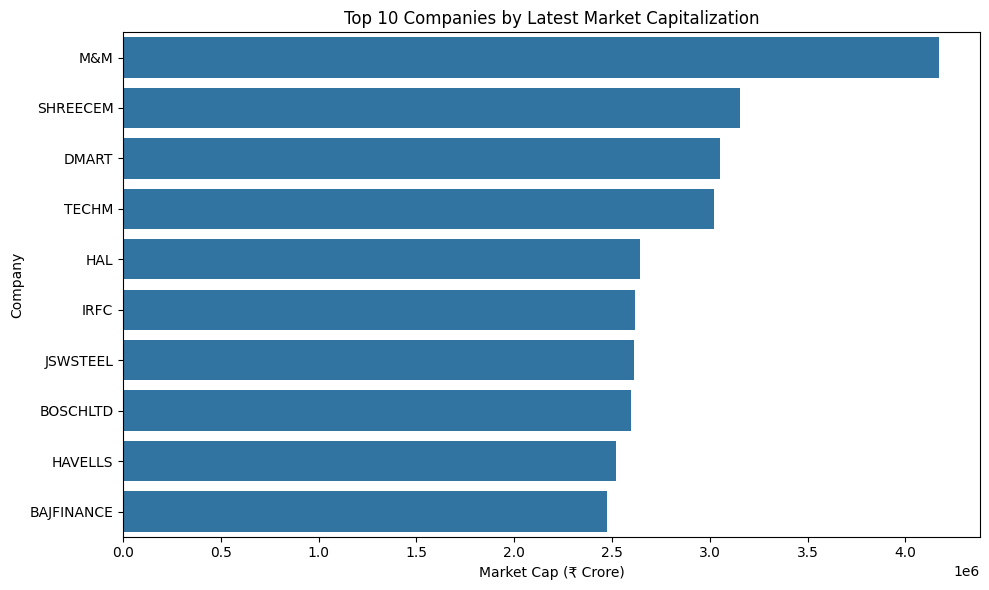

In [6]:
latest_mc = market_cap.loc[
    market_cap.groupby("company_id")["year"].idxmax()
].sort_values("market_cap_crore", ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=latest_mc, x="market_cap_crore", y="company_id")
plt.title("Top 10 Companies by Latest Market Capitalization")
plt.xlabel("Market Cap (₹ Crore)")
plt.ylabel("Company")
plt.tight_layout()
plt.show()

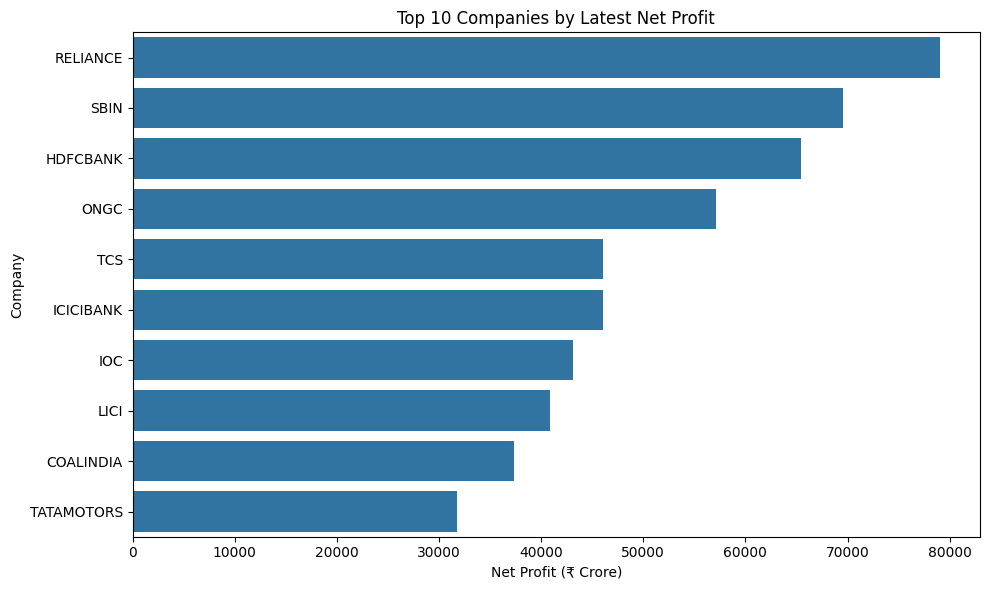

In [7]:
latest_pnl = pnl.loc[
    pnl.groupby("company_id")["year"].idxmax()
].sort_values("net_profit", ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=latest_pnl, x="net_profit", y="company_id")
plt.title("Top 10 Companies by Latest Net Profit")
plt.xlabel("Net Profit (₹ Crore)")
plt.ylabel("Company")
plt.tight_layout()
plt.show()

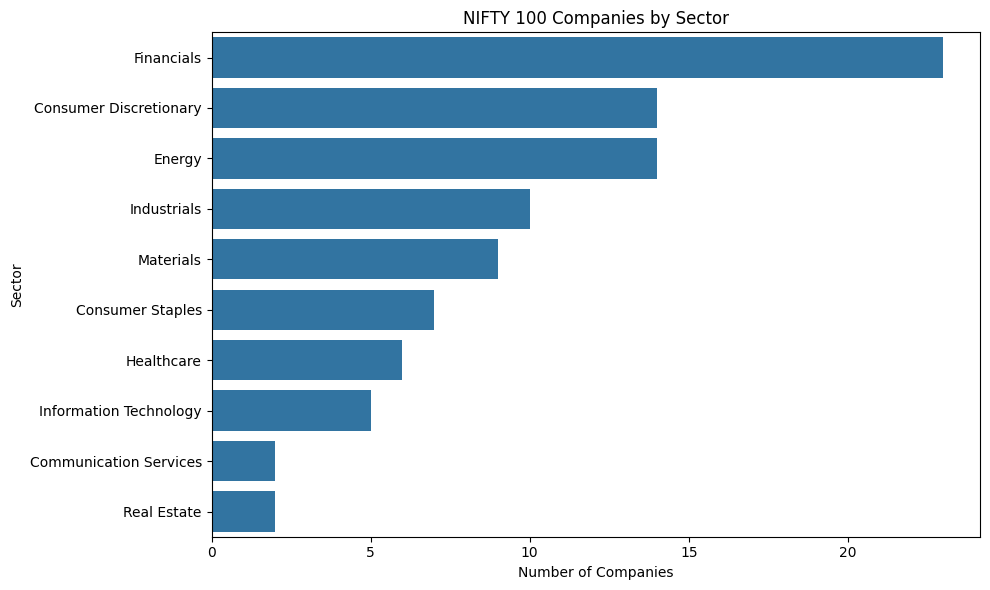

In [8]:
sector_count = (
    sectors.groupby("broad_sector")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="company_count")
)

plt.figure(figsize=(10,6))
sns.barplot(data=sector_count, x="company_count", y="broad_sector")
plt.title("NIFTY 100 Companies by Sector")
plt.xlabel("Number of Companies")
plt.ylabel("Sector")
plt.tight_layout()
plt.show()

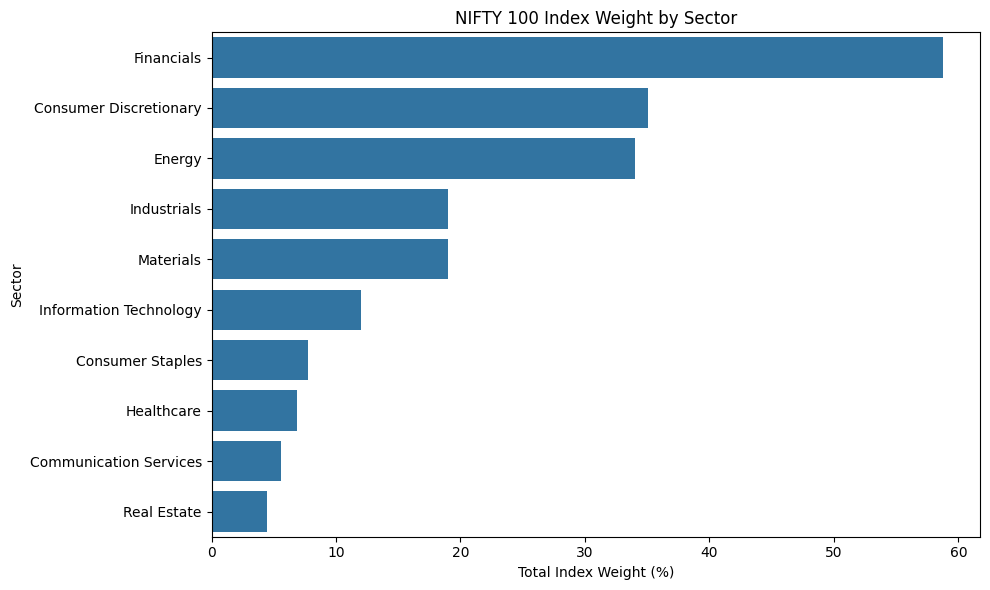

In [9]:
sector_weight = (
    sectors.groupby("broad_sector")["index_weight_pct"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10,6))
sns.barplot(data=sector_weight, x="index_weight_pct", y="broad_sector")
plt.title("NIFTY 100 Index Weight by Sector")
plt.xlabel("Total Index Weight (%)")
plt.ylabel("Sector")
plt.tight_layout()
plt.show()

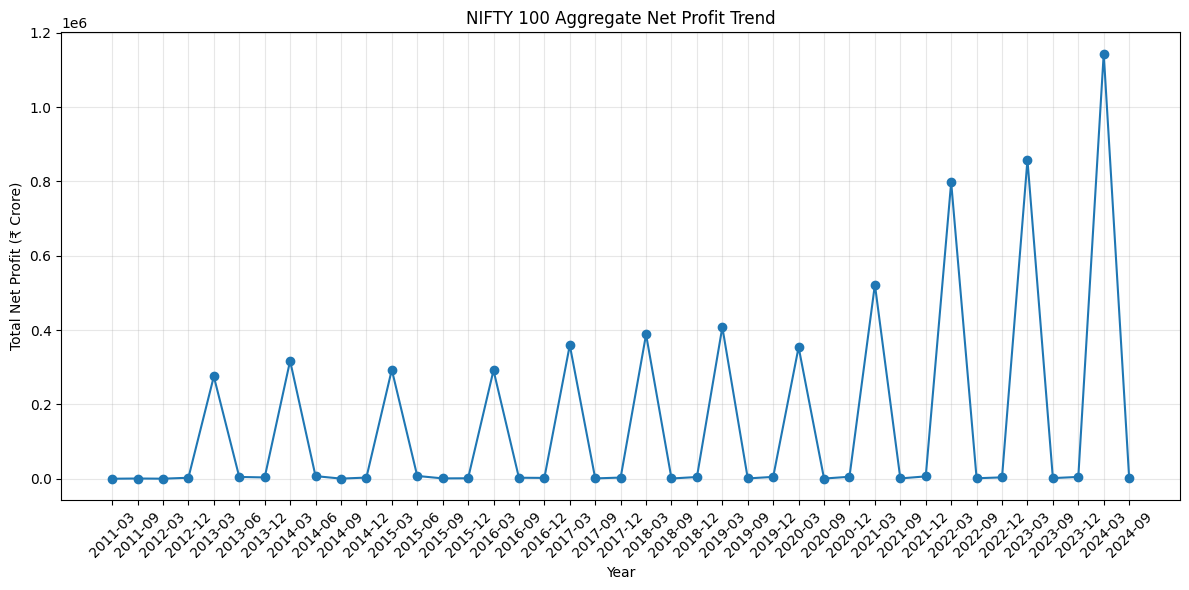

In [10]:
profit_trend = (
    pnl.groupby("year")["net_profit"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,6))
plt.plot(profit_trend["year"], profit_trend["net_profit"], marker="o")
plt.title("NIFTY 100 Aggregate Net Profit Trend")
plt.xlabel("Year")
plt.ylabel("Total Net Profit (₹ Crore)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

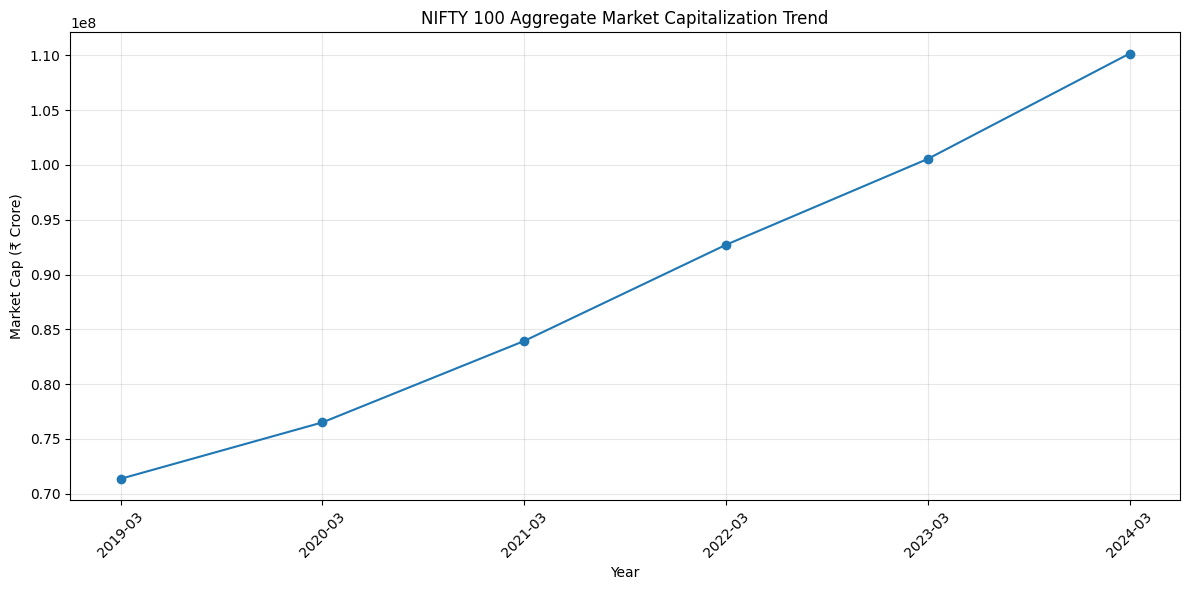

In [11]:
mc_trend = (
    market_cap.groupby("year")["market_cap_crore"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,6))
plt.plot(mc_trend["year"], mc_trend["market_cap_crore"], marker="o")
plt.title("NIFTY 100 Aggregate Market Capitalization Trend")
plt.xlabel("Year")
plt.ylabel("Market Cap (₹ Crore)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
stock_prices["date"] = pd.to_datetime(stock_prices["date"], errors="coerce")

print("Date range:")
print(stock_prices["date"].min(), "to", stock_prices["date"].max())

print("\nTotal records:", len(stock_prices))
print("Companies:", stock_prices["company_id"].nunique())

Date range:
2020-01-01 00:00:00 to 2024-12-01 00:00:00

Total records: 5520
Companies: 92


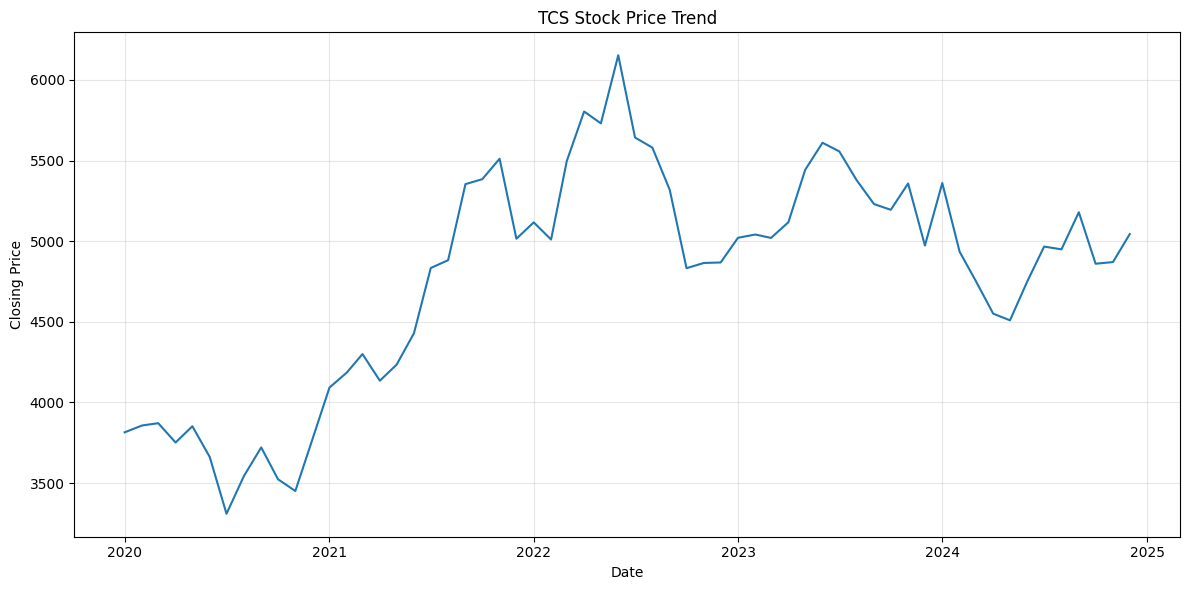

In [13]:
tcs = stock_prices[stock_prices["company_id"] == "TCS"].sort_values("date")

plt.figure(figsize=(12,6))
plt.plot(tcs["date"], tcs["close_price"])
plt.title("TCS Stock Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
latest_prices = stock_prices.loc[
    stock_prices.groupby("company_id")["date"].idxmax()
].sort_values("close_price", ascending=False).head(10)

display(latest_prices[["company_id", "date", "close_price"]])

,company_id,date,close_price
3179,ITC,2024-12-01,13452.44
3059,IRCTC,2024-12-01,11199.06
2099,GRASIM,2024-12-01,10518.26
3299,JIOFIN,2024-12-01,9945.52
4199,ONGC,2024-12-01,9807.29
3239,JINDALSTEL,2024-12-01,9322.13
4079,NHPC,2024-12-01,8867.11
179,ADANIENT,2024-12-01,8686.54
719,BAJAJ-AUTO,2024-12-01,8093.27
4619,SBILIFE,2024-12-01,8028.33


In [15]:
stock_prices = stock_prices.sort_values(["company_id", "date"])

stock_prices["daily_return_pct"] = (
    stock_prices.groupby("company_id")["close_price"]
    .pct_change() * 100
)

display(
    stock_prices[
        ["company_id", "date", "close_price", "daily_return_pct"]
    ].head(20)
)

,company_id,date,close_price,daily_return_pct
0,ABB,2020-01-01,1964.30,NaN
1,ABB,2020-02-01,2165.21,10.228071
2,ABB,2020-03-01,2198.78,1.550427
3,ABB,2020-04-01,1958.56,-10.925149
4,ABB,2020-05-01,2085.72,6.492525
5,ABB,2020-06-01,2147.71,2.972115
6,ABB,2020-07-01,2118.66,-1.352603
7,ABB,2020-08-01,1953.81,-7.780861
8,ABB,2020-09-01,1954.44,0.032245
9,ABB,2020-10-01,2021.36,3.423999


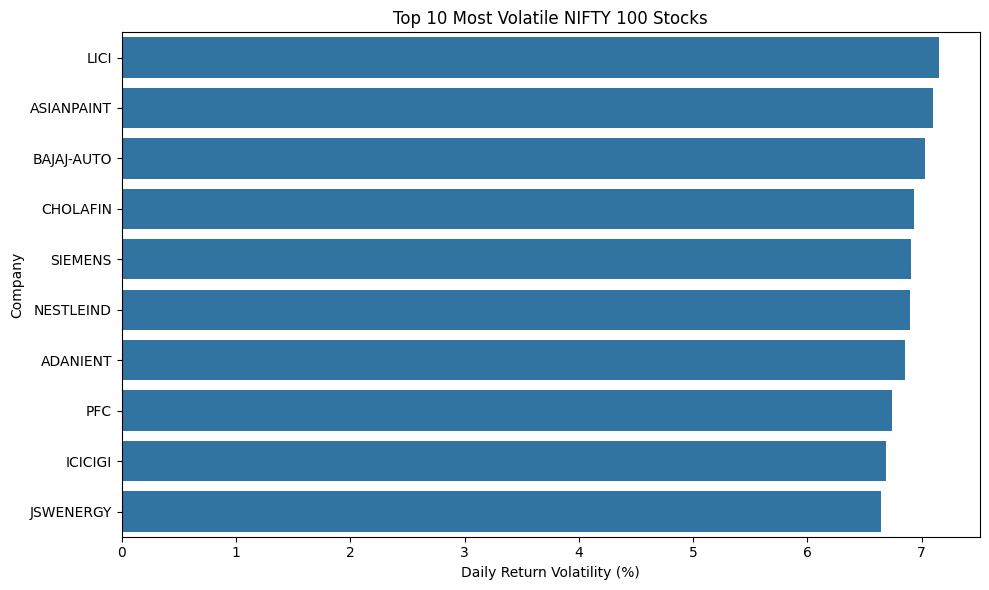

In [16]:
volatility = (
    stock_prices.groupby("company_id")["daily_return_pct"]
    .std()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="volatility")
)

plt.figure(figsize=(10,6))
sns.barplot(data=volatility, x="volatility", y="company_id")
plt.title("Top 10 Most Volatile NIFTY 100 Stocks")
plt.xlabel("Daily Return Volatility (%)")
plt.ylabel("Company")
plt.tight_layout()
plt.show()

In [17]:
# Latest financial ratios for each company

latest_ratios = ratios.loc[
    ratios.groupby("company_id")["year"].idxmax()
].copy()

display(
    latest_ratios[
        [
            "company_id",
            "year",
            "net_profit_margin_pct",
            "return_on_equity_pct",
            "debt_to_equity",
            "interest_coverage"
        ]
    ].head(10)
)

,company_id,year,net_profit_margin_pct,return_on_equity_pct,debt_to_equity,interest_coverage
11,ABB,2024-03,20.53,32.47,0.0224,141.7500
22,ADANIENSOL,2024-03,7.20,9.46,2.9325,2.2848
34,ADANIENT,2024-03,3.46,8.53,1.6714,2.7493
42,ADANIGREEN,2024-03,13.67,12.81,6.5953,1.7139
54,ADANIPORTS,2024-03,30.34,15.35,0.9373,5.9495
66,ADANIPOWER,2024-03,41.37,48.28,0.8023,8.2972
77,AMBUJACEM,2024-03,14.29,11.43,0.0169,28.2645
89,APOLLOHOSP,2024-03,4.91,13.48,0.7689,5.5657
101,ASIANPAINT,2024-03,15.66,29.68,0.1321,41.0049
125,AXISBANK,2024-03,22.73,15.83,8.2491,1.6912


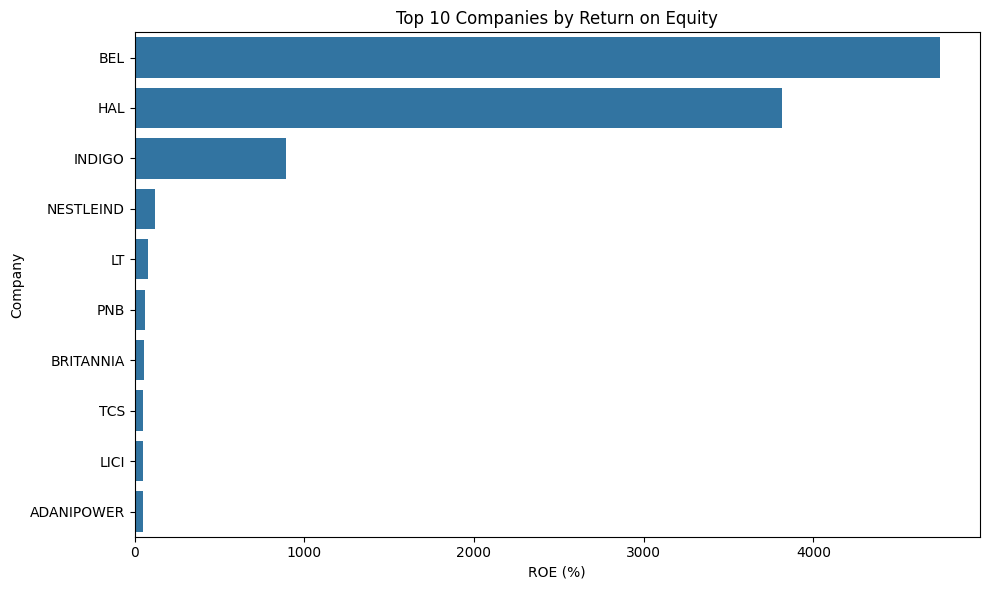

In [18]:
roe = (
    latest_ratios[
        ["company_id", "return_on_equity_pct"]
    ]
    .dropna()
    .sort_values("return_on_equity_pct", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
sns.barplot(data=roe, x="return_on_equity_pct", y="company_id")
plt.title("Top 10 Companies by Return on Equity")
plt.xlabel("ROE (%)")
plt.ylabel("Company")
plt.tight_layout()
plt.show()

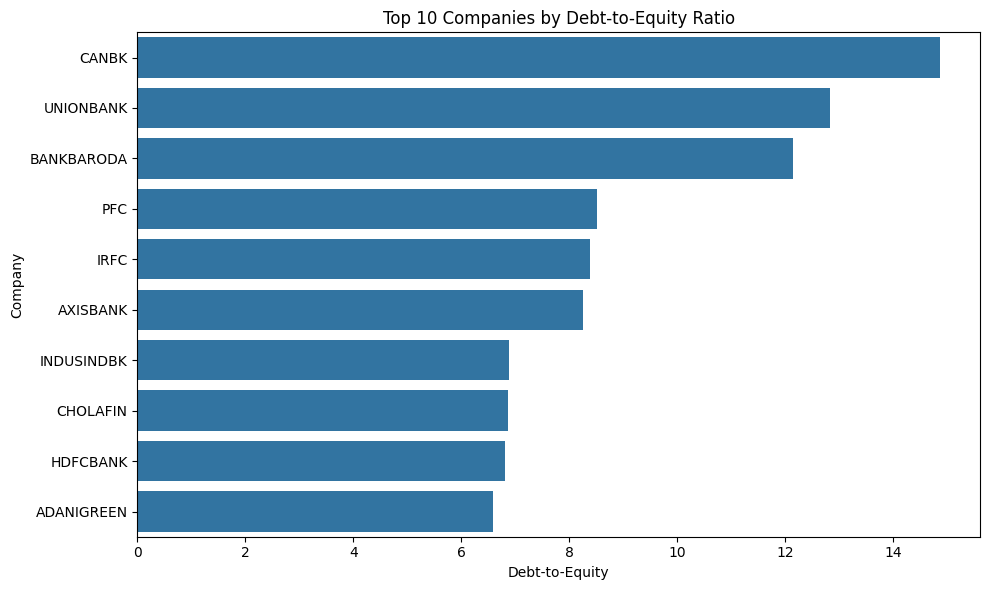

In [19]:
debt = (
    latest_ratios[
        ["company_id", "debt_to_equity"]
    ]
    .dropna()
    .sort_values("debt_to_equity", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
sns.barplot(data=debt, x="debt_to_equity", y="company_id")
plt.title("Top 10 Companies by Debt-to-Equity Ratio")
plt.xlabel("Debt-to-Equity")
plt.ylabel("Company")
plt.tight_layout()
plt.show()

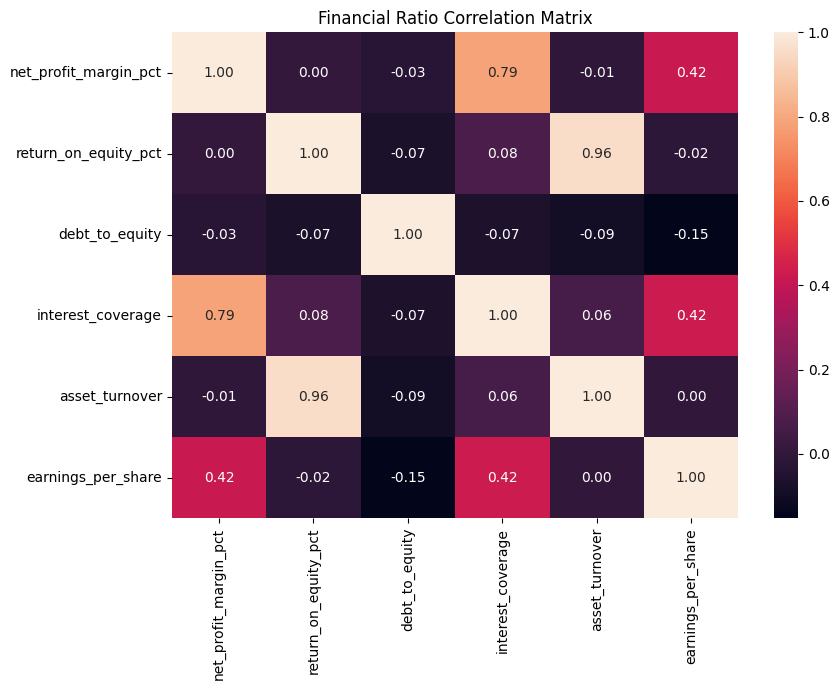

In [20]:
corr_cols = [
    "net_profit_margin_pct",
    "return_on_equity_pct",
    "debt_to_equity",
    "interest_coverage",
    "asset_turnover",
    "earnings_per_share"
]

corr = latest_ratios[corr_cols].corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Financial Ratio Correlation Matrix")
plt.tight_layout()
plt.show()

In [21]:
kpis = {
    "Companies": companies["id"].nunique(),
    "P&L Records": len(pnl),
    "Balance Sheet Records": len(bs),
    "Cash Flow Records": len(cf),
    "Market Cap Records": len(market_cap),
    "Stock Price Records": len(stock_prices),
    "Sectors": sectors["broad_sector"].nunique(),
    "Total Market Cap (Latest)": latest_mc["market_cap_crore"].sum(),
    "Total Net Profit (Latest)": latest_pnl["net_profit"].sum(),
}

display(pd.DataFrame(
    list(kpis.items()),
    columns=["KPI", "Value"]
))

,KPI,Value
0,Companies,100.00
1,P&L Records,1161.00
2,Balance Sheet Records,1220.00
3,Cash Flow Records,1152.00
4,Market Cap Records,552.00
5,Stock Price Records,5520.00
6,Sectors,10.00
7,Total Market Cap (Latest),28870576.74
8,Total Net Profit (Latest),516543.00


In [22]:
# Latest company-level summary for Power BI

summary = (
    latest_mc[["company_id", "year", "market_cap_crore"]]
    .merge(
        latest_pnl[["company_id", "net_profit", "sales", "eps"]],
        on="company_id",
        how="left"
    )
    .merge(
        latest_ratios[
            [
                "company_id",
                "net_profit_margin_pct",
                "return_on_equity_pct",
                "debt_to_equity"
            ]
        ],
        on="company_id",
        how="left"
    )
    .merge(
        sectors[
            [
                "company_id",
                "broad_sector",
                "sub_sector",
                "index_weight_pct"
            ]
        ],
        on="company_id",
        how="left"
    )
)

print("Dashboard summary:", summary.shape)
display(summary.head())

Dashboard summary: (10, 12)


,company_id,year,market_cap_crore,net_profit,sales,eps,net_profit_margin_pct,return_on_equity_pct,debt_to_equity,broad_sector,sub_sector,index_weight_pct
0,M&M,2024-03,4173085.48,NaN,NaN,NaN,8.82,18.54,1.6414,Consumer Discretionary,Automobiles,3.95
1,SHREECEM,2024-03,3154358.33,NaN,NaN,NaN,8.45,8.37,0.0800,Materials,Cement,2.86
2,DMART,2024-03,3053088.97,NaN,NaN,NaN,4.99,13.56,0.0317,Consumer Discretionary,Retail,3.07
3,TECHM,2024-03,3021095.64,NaN,NaN,NaN,4.61,8.99,0.0951,Information Technology,IT Services,2.39
4,HAL,2024-03,2643616.86,NaN,NaN,NaN,25.00,3816.58,0.6181,Industrials,Defence & Aerospace,1.60


In [23]:
# Complete latest-year datasets for ALL companies

all_latest_mc = market_cap.loc[
    market_cap.groupby("company_id")["year"].idxmax()
]

all_latest_pnl = pnl.loc[
    pnl.groupby("company_id")["year"].idxmax()
]

all_latest_ratios = ratios.loc[
    ratios.groupby("company_id")["year"].idxmax()
]

summary = (
    all_latest_mc[
        ["company_id", "year", "market_cap_crore"]
    ]
    .merge(
        all_latest_pnl[
            ["company_id", "net_profit", "sales", "eps"]
        ],
        on="company_id",
        how="left"
    )
    .merge(
        all_latest_ratios[
            [
                "company_id",
                "net_profit_margin_pct",
                "return_on_equity_pct",
                "debt_to_equity"
            ]
        ],
        on="company_id",
        how="left"
    )
    .merge(
        sectors[
            [
                "company_id",
                "broad_sector",
                "sub_sector",
                "index_weight_pct"
            ]
        ],
        on="company_id",
        how="left"
    )
)

print("Final dashboard dataset:", summary.shape)
display(summary.head())

Final dashboard dataset: (92, 12)


,company_id,year,market_cap_crore,net_profit,sales,eps,net_profit_margin_pct,return_on_equity_pct,debt_to_equity,broad_sector,sub_sector,index_weight_pct
0,ABB,2024-03,1536236.24,1201,5849,565.0,20.53,32.47,0.0224,Industrials,Capital Goods,0.81
1,ADANIENSOL,2024-03,348517.36,1196,16607,10.0,7.20,9.46,2.9325,Energy,Power & Utilities,0.65
2,ADANIENT,2024-03,187927.97,3335,96421,28.0,3.46,8.53,1.6714,Industrials,Conglomerates,1.50
3,ADANIGREEN,2024-03,510512.78,1260,9220,7.0,13.67,12.81,6.5953,Energy,Renewable Energy,1.23
4,ADANIPORTS,2024-03,675598.01,8104,26711,38.0,30.34,15.35,0.9373,Industrials,Infrastructure,2.12


In [24]:
from pathlib import Path

Path("../data/processed").mkdir(parents=True, exist_ok=True)

summary.to_csv(
    "../data/processed/company_dashboard.csv",
    index=False
)

print("Saved: data/processed/company_dashboard.csv")

Saved: data/processed/company_dashboard.csv


In [25]:
sector_dashboard = (
    sectors.groupby("broad_sector")
    .agg(
        company_count=("company_id", "count"),
        total_index_weight=("index_weight_pct", "sum")
    )
    .reset_index()
    .sort_values("total_index_weight", ascending=False)
)

sector_dashboard.to_csv(
    "../data/processed/sector_dashboard.csv",
    index=False
)

print("Saved: data/processed/sector_dashboard.csv")

Saved: data/processed/sector_dashboard.csv


In [26]:
stock_prices.to_csv(
    "../data/processed/stock_prices_dashboard.csv",
    index=False
)

print("Saved: data/processed/stock_prices_dashboard.csv")

Saved: data/processed/stock_prices_dashboard.csv
